In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats

In [157]:
MODEL_COLORS = {
    "actual":"#0055ff",
    "ECMWF":"#de0000",
    "rf_prediction":"#4dc11c",
    "xgb_predicted":"#c77cff",
    "SSA-LSTM":"#ff7700",
    "ensemble_rf_pred":"#00DDFF",
}

MODEL_LABELS = {
    "ECMWF": "ECMWF",
    "rf_prediction": "Random Forest",
    "xgb_predicted": "XGBoost",
    "SSA-LSTM": "SSA-LSTM",
    "ensemble_rf_pred": "Ansamblis (RF)",
}

KATEGORIJU_TVARKA = [
    "0: Nėra lietaus (0 mm)",
    "1: Silpnas (0-10 mm)",
    "2: Vidutinis (10-30 mm)",
    "3: Stiprus (>30 mm)",
]

In [158]:
df = pd.read_csv("All_predictions.csv")
df['observationTime'] = pd.to_datetime(df['observationTime'])
df.columns.to_list()

['observationTime',
 'rf_prediction',
 'actual',
 'ECMWF',
 'xgb_predicted',
 'SSA-LSTM']

In [159]:
pradzia = df['observationTime'].min()
pabaiga = df['observationTime'].max()
print(pradzia, pabaiga)

2024-08-11 00:00:00 2026-01-30 00:00:00


In [160]:
def gauti_kategorija(x):
    if x == 0:
        return "0: Nėra lietaus (0 mm)"
    elif x <= 10:
        return "1: Silpnas (0-10 mm)"
    elif x <= 30:
        return "2: Vidutinis (10-30 mm)"
    else:
        return "3: Stiprus (>30 mm)"


def prideti_klaidas(data, model_cols, target_col="actual"):
    d = data.copy()
    for col in model_cols:
        d[f"Error_{col}"] = d[col] - d[target_col]
    return d


def calculate_metrics(y_true, y_pred, model_name):
    return {
        "Modelis": model_name,
        "R^2":  round(r2_score(y_true, y_pred), 4),
        "MAE":  round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "r_s":  round(stats.spearmanr(y_true, y_pred)[0], 4),
    }


def metrikos_lentele(data, model_cols, target_col="actual"):
    results = [calculate_metrics(data[target_col], data[m], MODEL_LABELS.get(m, m))
               for m in model_cols]
    return pd.DataFrame(results)

# Grafikų funckijos

In [161]:
def plot_prognozes_matplotlib(data, model_cols, target_col="actual", nuo=None, iki=None):
    d = data.copy()
    if nuo is not None:
        d = d[d['observationTime'] >= pd.Timestamp(nuo)]
    if iki is not None:
        d = d[d['observationTime'] <= pd.Timestamp(iki)]

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(d['observationTime'], d[target_col],
            label='Tikra', color=MODEL_COLORS['actual'], linewidth=1)
    for col in model_cols:
        ax.plot(d['observationTime'], d[col],
                label=MODEL_LABELS.get(col, col),
                color=MODEL_COLORS.get(col, None),
                linewidth=1.5, linestyle='--')
    ax.set_xlabel('Data')
    ax.set_ylabel('Krituliai (mm)')
    title = 'Modelių prognozių palyginimas'
    if nuo or iki:
        title += f"  [{nuo or '...'} - {iki or '...'}]"
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [162]:
def plot_prognozes_plotly(data, model_cols, target_col="actual"):
    dash_styles = ['dot', 'dash', 'dashdot', 'longdash', 'longdashdot']
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=data['observationTime'], y=data[target_col],
        name='Tikra', line=dict(color=MODEL_COLORS['actual'], width=1.5)
    ))
    for i, col in enumerate(model_cols):
        fig.add_trace(go.Scatter(
            x=data['observationTime'], y=data[col],
            name=MODEL_LABELS.get(col, col),
            line=dict(color=MODEL_COLORS.get(col), width=1, dash=dash_styles[i % len(dash_styles)])
        ))
    fig.update_layout(
        title='Modelių prognozių palyginimas',
        xaxis_title='Data', yaxis_title='Krituliai (mm)',
        hovermode='x unified',
        xaxis=dict(rangeslider=dict(visible=True)),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
    )
    fig.show()

In [163]:
def plot_error_heatmap(data, model_cols, target_col="actual"):
    d = prideti_klaidas(data, model_cols, target_col)
    error_cols = [f"Error_{c}" for c in model_cols]
    heatmap_data = d[error_cols].T
    heatmap_data.index = [MODEL_LABELS.get(c, c) for c in model_cols]
    plt.figure(figsize=(18, 4))
    sns.heatmap(heatmap_data, cmap='coolwarm', center=0,
                cbar_kws={'label': 'Paklaida (mm)'})
    plt.title('Modelių prognozių paklaidų šilumos žemėlapis', fontsize=14)
    plt.xlabel('Diena')
    plt.ylabel('Modeliai')
    plt.tight_layout()
    plt.show()

In [164]:
def plot_monthly_error_heatmap(data, model_cols, target_col="actual"):
    d = prideti_klaidas(data, model_cols, target_col)
    d['Metai_Mėnesis'] = d['observationTime'].dt.to_period('M')
    error_cols = [f"Error_{c}" for c in model_cols]
    monthly = d.groupby('Metai_Mėnesis')[error_cols].mean().T
    monthly.index = [MODEL_LABELS.get(c, c) for c in model_cols]
    monthly.columns = monthly.columns.astype(str)
    plt.figure(figsize=(12, 4))
    sns.heatmap(monthly, cmap='coolwarm', center=0,
                annot=True, fmt=".1f",
                cbar_kws={'label': 'Vidutinė mėnesio paklaida (mm)'})
    plt.title('Vidutinė modelių prognozių paklaida pagal mėnesius', fontsize=12)
    plt.xlabel('Laikotarpis (Metai-Mėnesis)')
    plt.ylabel('Modeliai')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [165]:
def plot_boxplot_klaidos(data, model_cols, target_col="actual", standartizuotos=False):
    d = data.copy()
    for col in model_cols:
        if standartizuotos:
            d[f"Error_{col}"] = np.where(
                d[target_col] > 0,
                ((d[col] - d[target_col]) / d[target_col]) * 100,
                d[col] - d[target_col]
            )
        else:
            d[f"Error_{col}"] = d[col] - d[target_col]

    d["Kritulių_Dydis"] = pd.Categorical(
        d[target_col].apply(gauti_kategorija),
        categories=KATEGORIJU_TVARKA, ordered=True
    )
    error_cols = [f"Error_{c}" for c in model_cols]
    df_long = pd.melt(d, id_vars=["Kritulių_Dydis"], value_vars=error_cols,
                      var_name="Modelis", value_name="Paklaida")
    df_long["Modelis"] = df_long["Modelis"].str.replace("Error_", "", regex=False)
    df_long["Modelis"] = df_long["Modelis"].map(lambda x: MODEL_LABELS.get(x, x))

    palette = [MODEL_COLORS.get(c) for c in model_cols]
    plt.figure(figsize=(11, 6))
    sns.boxplot(x="Kritulių_Dydis", y="Paklaida", hue="Modelis",
                data=df_long, palette=palette, showfliers=False)
    plt.axhline(0, color="red", linestyle="--", alpha=0.7)
    title = ("Standartizuotos modelių paklaidos pagal kritulių dydį"
             if standartizuotos else
             "Modelių paklaidos priklausomai nuo faktinio kritulių dydžio")
    plt.title(title, fontsize=12, weight="bold")
    plt.xlabel("Faktinis kritulių kiekis", fontsize=10)
    plt.ylabel("Prognozės paklaida " + ("(%)" if standartizuotos else "(mm)"), fontsize=10)
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.legend(title="Modelis")
    plt.tight_layout()
    plt.show()

In [166]:
def plot_density(data, model_cols, target_col="actual", xlim=(-20, 20)):
    d = prideti_klaidas(data, model_cols, target_col)
    plt.figure(figsize=(9, 5))
    for col in model_cols:
        sns.kdeplot(data=d[f"Error_{col}"],
                    label=MODEL_LABELS.get(col, col),
                    color=MODEL_COLORS.get(col),
                    linewidth=1, fill=False, alpha=1)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1,
                label='Ideali prognozė (Paklaida = 0)')
    plt.xlim(xlim)
    plt.title('Modelių prognozių paklaidų tankio pasiskirstymas', fontsize=11, weight='bold')
    plt.xlabel('Prognozės paklaida (mm)', fontsize=9)
    plt.ylabel('Tankis', fontsize=9)
    plt.grid(True, linestyle=':', alpha=0.5, color='#cccccc')
    plt.legend(loc='upper right', fontsize=8.5)
    plt.tight_layout()
    plt.show()

In [167]:
def plot_cumsum(data, model_cols, target_col="actual"):
    d = data.copy()
    d['_actual_cum'] = d[target_col].cumsum()
    dash_styles = ['--', ':', '-.', (0, (5, 2)), (0, (3, 1, 1, 1))]
    fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
    ax.plot(d['observationTime'], d['_actual_cum'],
            label='Tikra', color=MODEL_COLORS['actual'], linewidth=1.5)
    for i, col in enumerate(model_cols):
        d[f'_{col}_cum'] = d[col].cumsum()
        ax.plot(d['observationTime'], d[f'_{col}_cum'],
                label=MODEL_LABELS.get(col, col),
                color=MODEL_COLORS.get(col),
                linewidth=1.2, linestyle=dash_styles[i % len(dash_styles)])
    ax.set_ylabel("Krituliai (mm)", fontsize=8)
    ax.set_xlabel("Laikas", fontsize=8)
    ax.set_title("Kaupiamoji kritulių suma", fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
    ax.legend(loc='upper left', fontsize=7.5, frameon=True,
              facecolor='white', edgecolor='black', framealpha=0.9)
    plt.show()

In [168]:
def plot_scatter_log(data, model_cols, target_col="actual"):
    n = len(model_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows),
                              sharex=True, sharey=True)
    axes = axes.flatten()
    x_val = np.log1p(data[target_col])
    for i, col in enumerate(model_cols):
        ax = axes[i]
        y_val = np.log1p(data[col].clip(lower=0))
        sns.regplot(x=x_val, y=y_val, ax=ax, color=MODEL_COLORS.get(col),
                    scatter_kws={'alpha': 0.4, 's': 8},
                    line_kws={'color': 'red', 'linewidth': 1.5, 'label': 'Modelio tendencija'})
        max_limit = max(x_val.max(), y_val.max())
        ax.plot([0, max_limit], [0, max_limit], color='gray', linestyle='--',
                alpha=0.7, label='Ideali prognozė')
        ax.set_title(f"{MODEL_LABELS.get(col, col)} vs Tikri duomenys",
                     fontsize=11, weight='bold', pad=8)
        ax.set_xlabel("log(Tikri krituliai + 1)", fontsize=9)
        ax.set_ylabel(f"log(Prognozė + 1)", fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.5, color='#cccccc')
        ax.tick_params(axis='both', labelsize=8)
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

In [169]:
def plot_qq(data, model_cols, target_col="actual"):
    n = len(model_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
    axes = axes.flatten()
    actual_sorted = np.sort(data[target_col])
    for i, col in enumerate(model_cols):
        ax = axes[i]
        model_sorted = np.sort(data[col].clip(lower=0))
        ax.scatter(actual_sorted, model_sorted,
                   color=MODEL_COLORS.get(col), s=20, alpha=1,
                   label=MODEL_LABELS.get(col, col), edgecolors='none')
        max_val = max(actual_sorted.max(), model_sorted.max()) * 1.05
        ax.plot([0, max_val], [0, max_val], color='gray', linestyle='--',
                alpha=0.7, label='Ideali atitiktis (y=x)')
        ax.set_xlim(-0.2, max_val)
        ax.set_ylim(-0.2, max_val)
        ax.set_title(f"{MODEL_LABELS.get(col, col)} Q-Q grafikas",
                     fontsize=11, weight='bold', pad=8)
        ax.set_xlabel("Faktinės reikšmės (surūšiuotos), mm", fontsize=9)
        ax.set_ylabel("Prognozuotos reikšmės (surūšiuotos), mm", fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.5, color='#cccccc')
        ax.tick_params(axis='both', labelsize=8)
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


In [170]:
def plot_confusion_matrices_rain(data, target_col, model_cols, rain_threshold=0.0):
    n = len(model_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)
    axes = axes.flatten()
    results = []
    for idx, col in enumerate(model_cols):
        y_true_bin = (data[target_col] > rain_threshold).astype(int)
        y_pred_bin = (data[col] > rain_threshold).astype(int)
        results.append({
            "Modelis":    MODEL_LABELS.get(col, col),
            "Accuracy":   round(accuracy_score(y_true_bin, y_pred_bin), 3),
            "Precision":  round(precision_score(y_true_bin, y_pred_bin, zero_division=0), 3),
            "Recall":     round(recall_score(y_true_bin, y_pred_bin, zero_division=0), 3),
            "F1-Score":   round(f1_score(y_true_bin, y_pred_bin, zero_division=0), 3),
        })
        cm = confusion_matrix(y_true_bin, y_pred_bin)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['Nelyja', 'Lyja'], yticklabels=['Nelyja', 'Lyja'],
                    cbar=False, ax=axes[idx], annot_kws={"size": 14, "weight": "bold"})
        axes[idx].set_title(f"Confusion Matrix: {MODEL_LABELS.get(col, col)}", fontsize=12, pad=10)
        axes[idx].set_xlabel("Prognozė", fontsize=11)
        axes[idx].set_ylabel("Tikra", fontsize=11)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(results)

In [171]:
def plot_confusion_matrices_kategorijos(data, model_cols, target_col="actual"):
    d = data.copy()
    d["Cat_Actual"] = d[target_col].apply(gauti_kategorija)
    for col in model_cols:
        d[f"Cat_{col}"] = d[col].apply(gauti_kategorija)

    n = len(model_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
    axes = axes.flatten()

    for idx, col in enumerate(model_cols):
        cm = confusion_matrix(d["Cat_Actual"], d[f"Cat_{col}"], labels=KATEGORIJU_TVARKA)
        cm_pct = np.nan_to_num(cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]) * 100
        labels = np.asarray(
            [f"{c}\n({p:.1f}%)" for c, p in zip(cm.flatten(), cm_pct.flatten())]
        ).reshape(4, 4)
        sns.heatmap(cm_pct, annot=labels, fmt="", cmap="Blues",
                    ax=axes[idx], xticklabels=["0", "1", "2", "3"],
                    yticklabels=["0", "1", "2", "3"],
                    cbar=False, linewidths=0.5, linecolor="gray")
        axes[idx].set_title(f"{MODEL_LABELS.get(col, col)} klasifikavimo matrica", fontsize=12)
        axes[idx].set_xlabel("Prognozuota kategorija", fontsize=10)
        axes[idx].set_ylabel("Tikra kategorija", fontsize=10)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        "Klasifikavimo matricos (% pagal faktinę kategoriją)\n"
        "0 - Nėra lietaus, 1 - Silpnas, 2 - Vidutinis, 3 - Stiprus",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

# Bendra aibė pagal LSTM

In [172]:
TARGET_COL = "actual"
MODEL_COLS = ["ECMWF", "rf_prediction", "xgb_predicted", "SSA-LSTM"]

In [173]:
metrikos = metrikos_lentele(df, MODEL_COLS, TARGET_COL)
print(metrikos.to_string(index=False))

      Modelis    R^2    MAE   RMSE    r_s
        ECMWF 0.3570 1.2996 3.0837 0.7410
Random Forest 0.5210 1.2477 2.6615 0.7033
      XGBoost 0.4735 1.2482 2.7904 0.6897
     SSA-LSTM 0.4101 1.3761 2.9537 0.6240


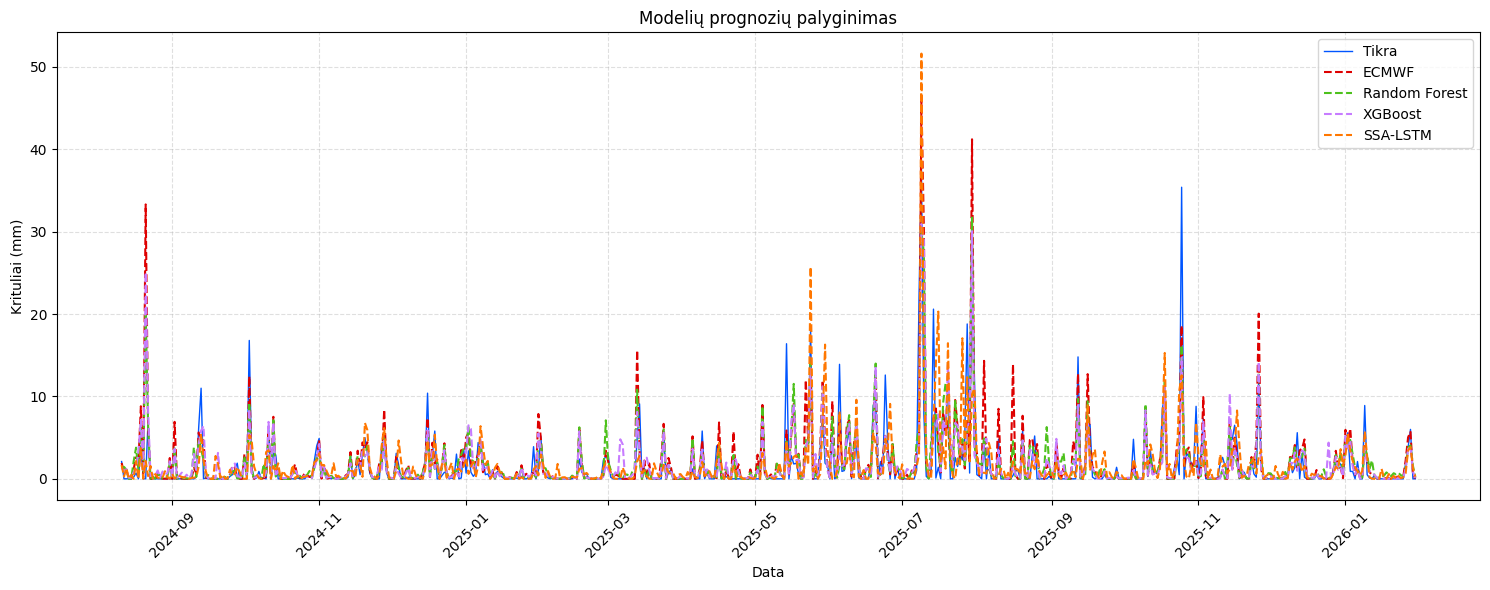

In [174]:
plot_prognozes_matplotlib(df, MODEL_COLS)

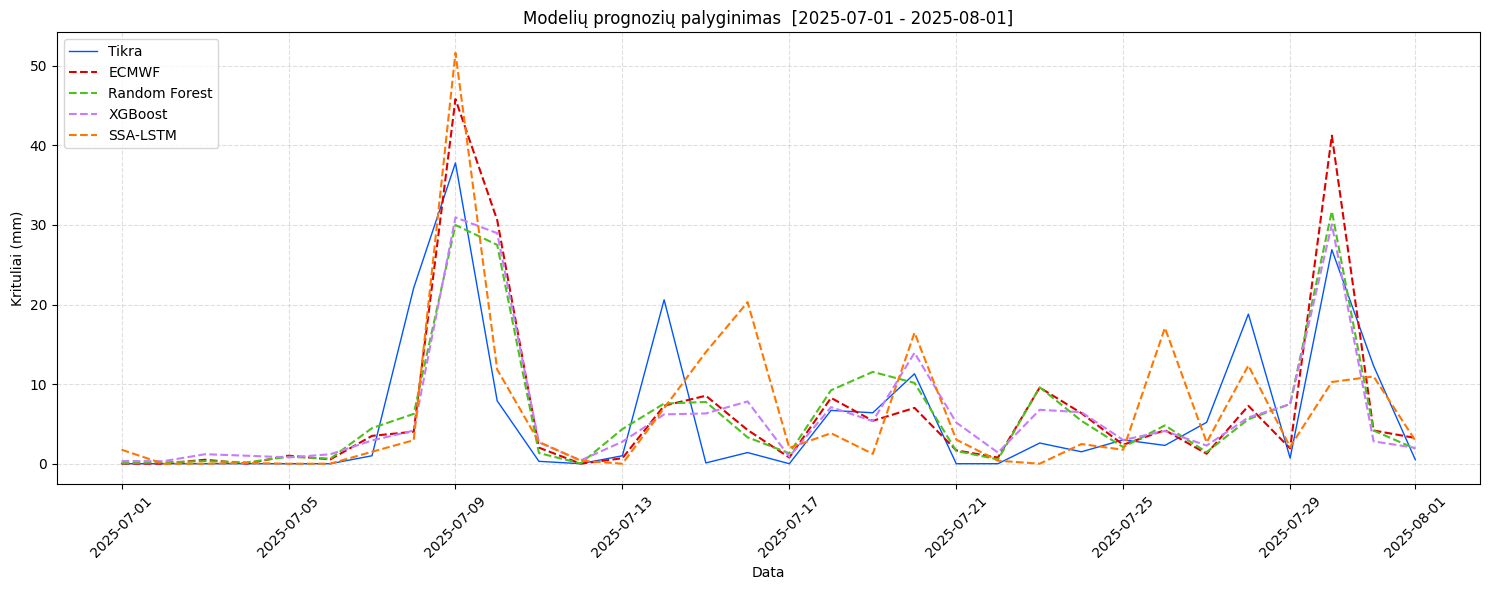

In [175]:
plot_prognozes_matplotlib(df, MODEL_COLS, nuo="2025-07-01", iki="2025-08-01")

In [176]:
plot_prognozes_plotly(df, MODEL_COLS)

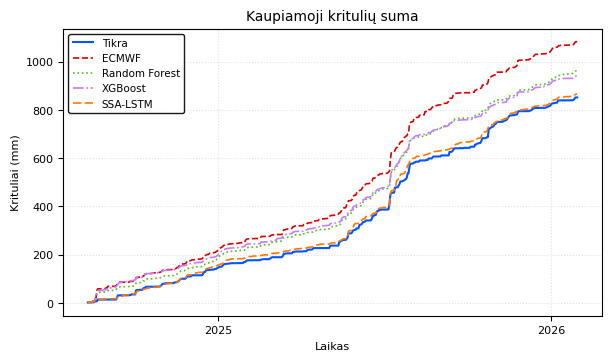

In [177]:
plot_cumsum(df, MODEL_COLS)

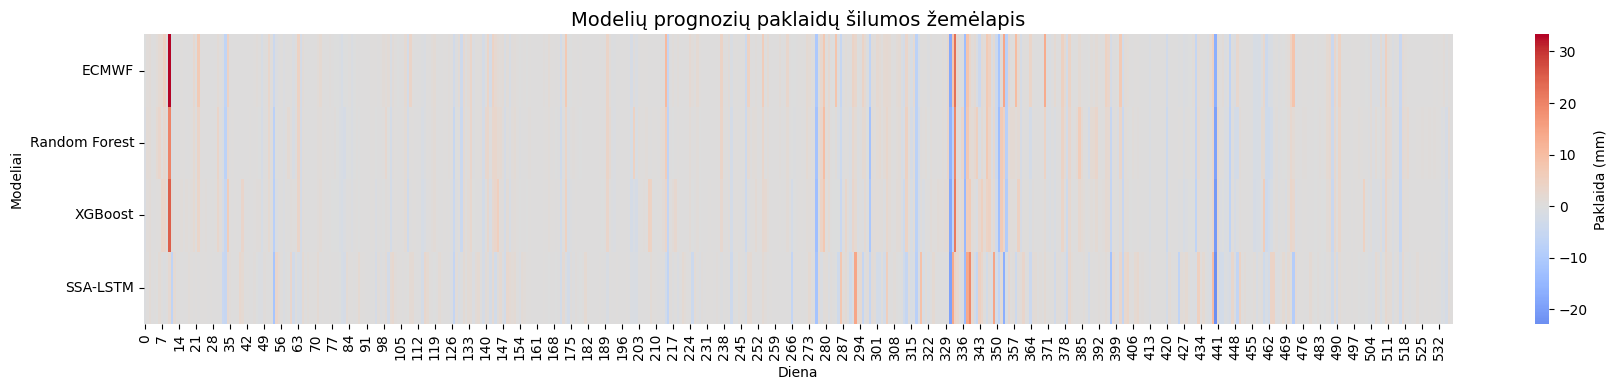

In [178]:
plot_error_heatmap(df, MODEL_COLS)

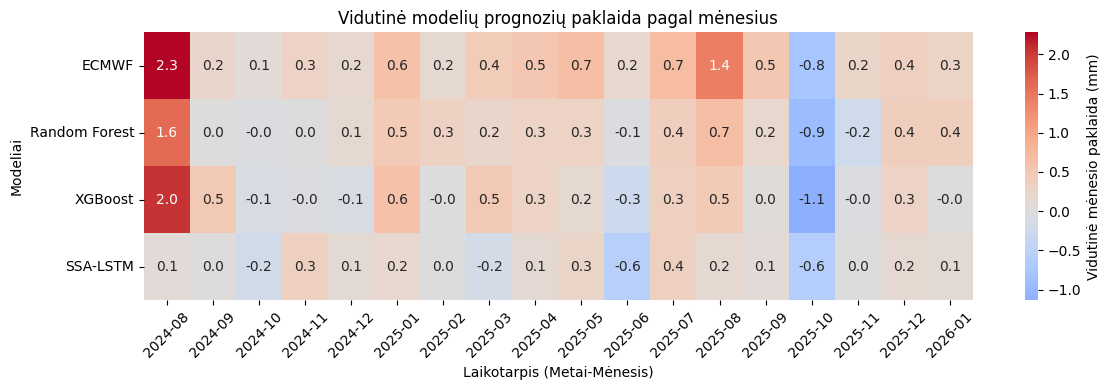

In [179]:
plot_monthly_error_heatmap(df, MODEL_COLS)

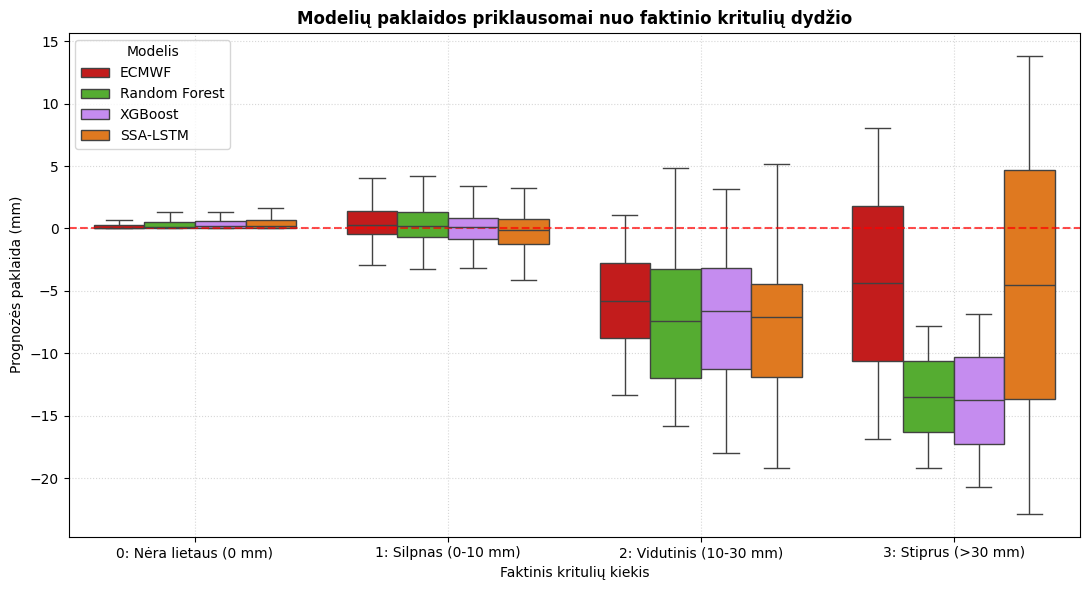

In [180]:
plot_boxplot_klaidos(df, MODEL_COLS)

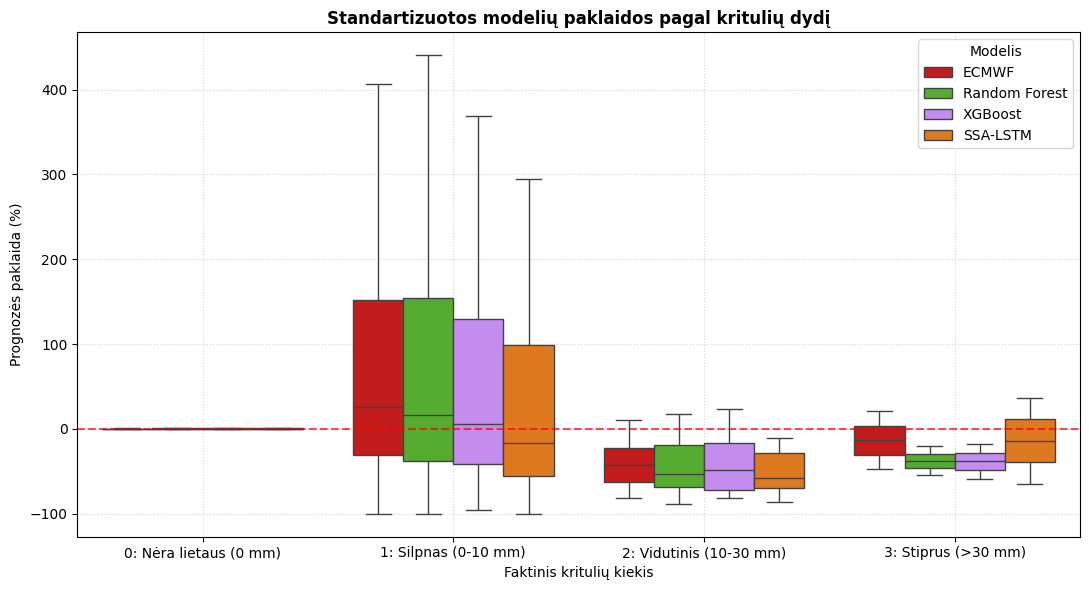

In [181]:
plot_boxplot_klaidos(df, MODEL_COLS, standartizuotos=True)

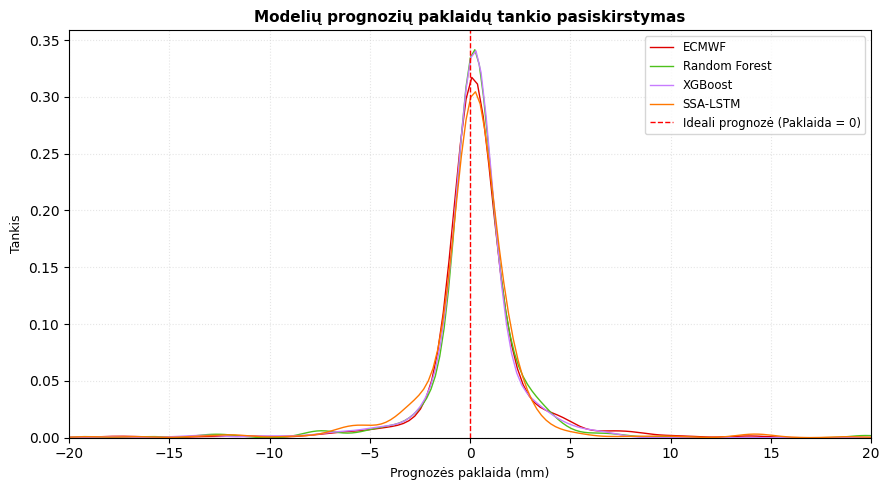

In [182]:
plot_density(df, MODEL_COLS)

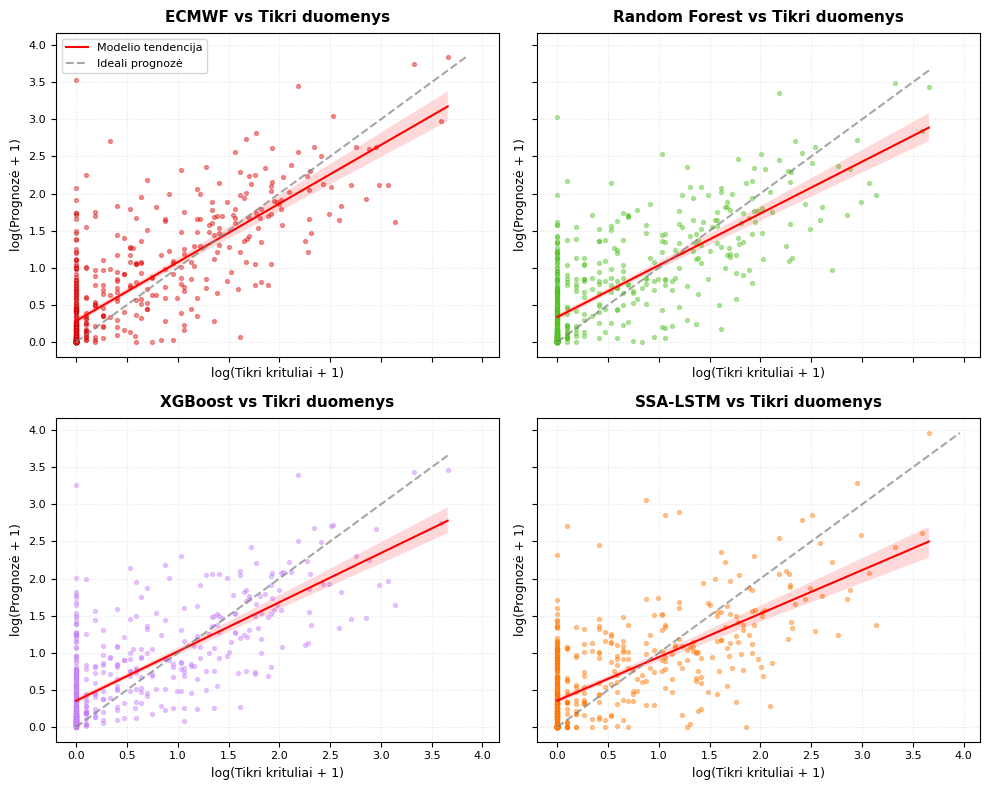

In [183]:
plot_scatter_log(df, MODEL_COLS)

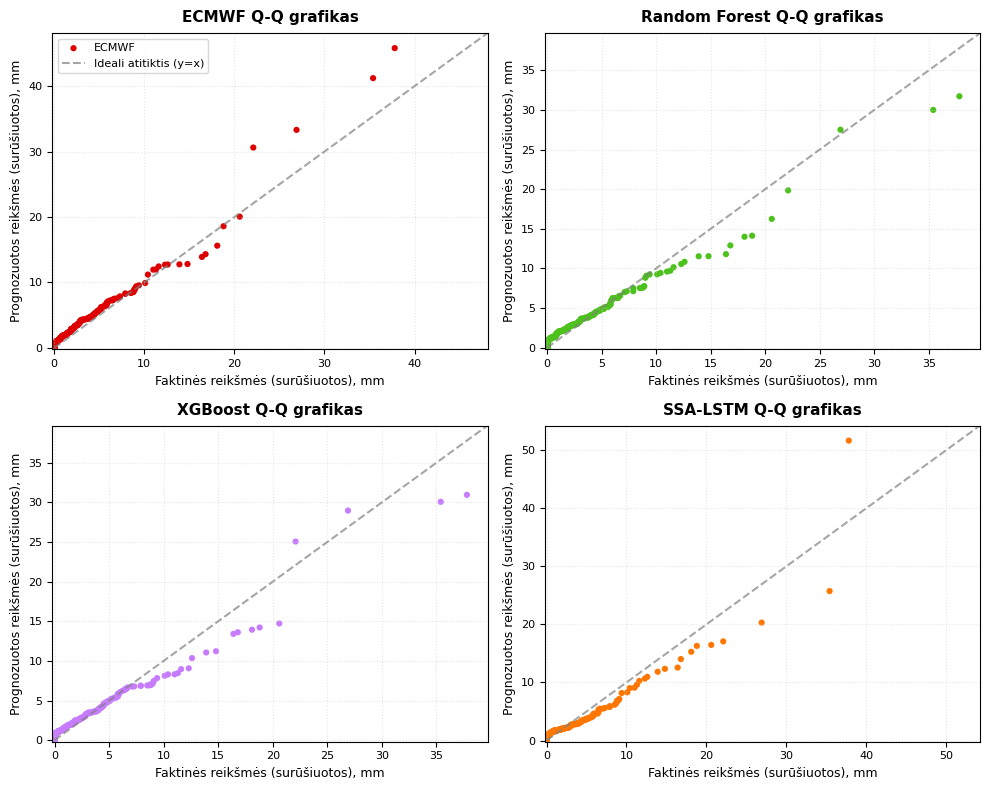

In [184]:
plot_qq(df, MODEL_COLS)

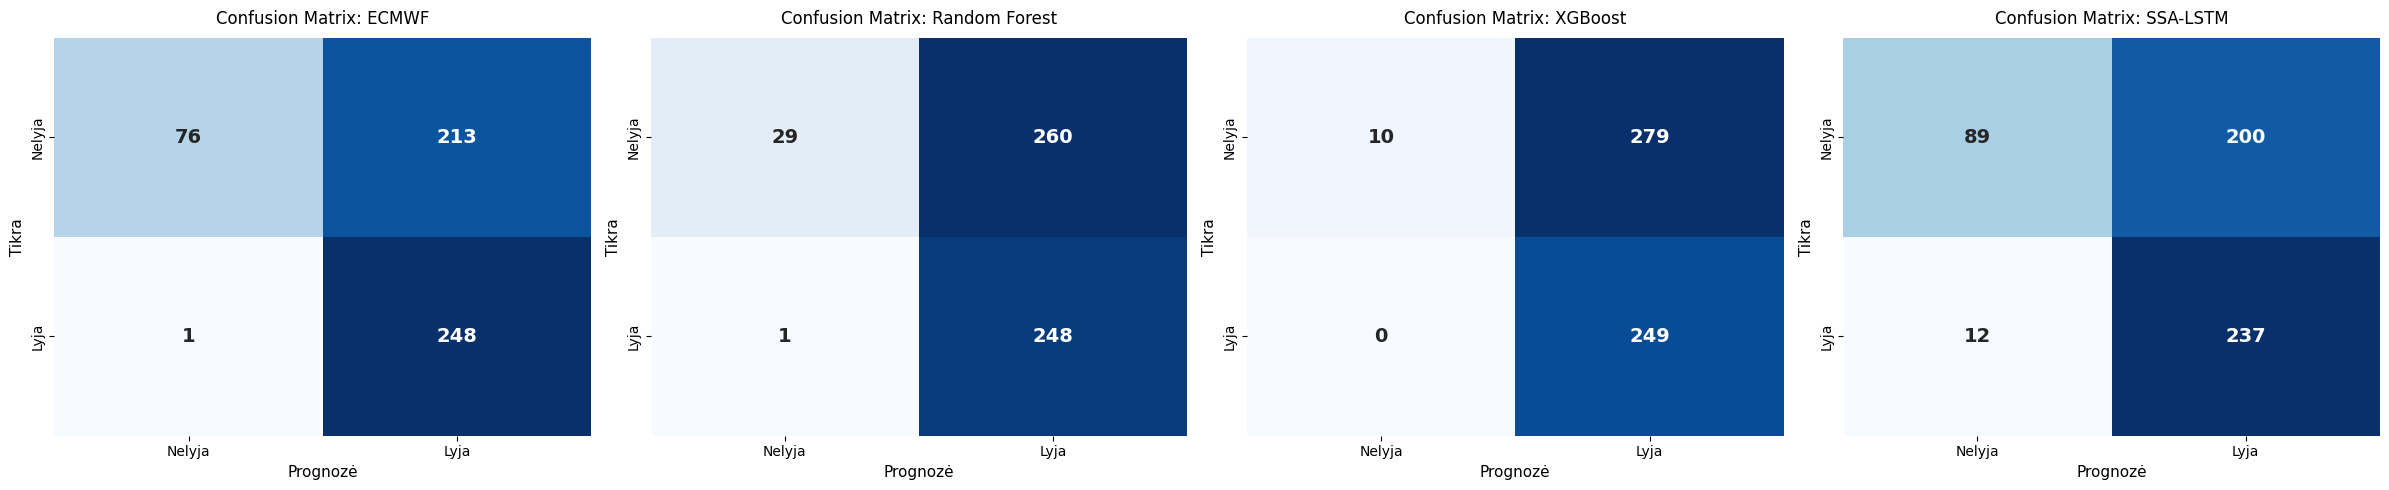

      Modelis  Accuracy  Precision  Recall  F1-Score
        ECMWF     0.602      0.538   0.996     0.699
Random Forest     0.515      0.488   0.996     0.655
      XGBoost     0.481      0.472   1.000     0.641
     SSA-LSTM     0.606      0.542   0.952     0.691


In [185]:
klasif = plot_confusion_matrices_rain(df, TARGET_COL, MODEL_COLS)
print(klasif.to_string(index=False))

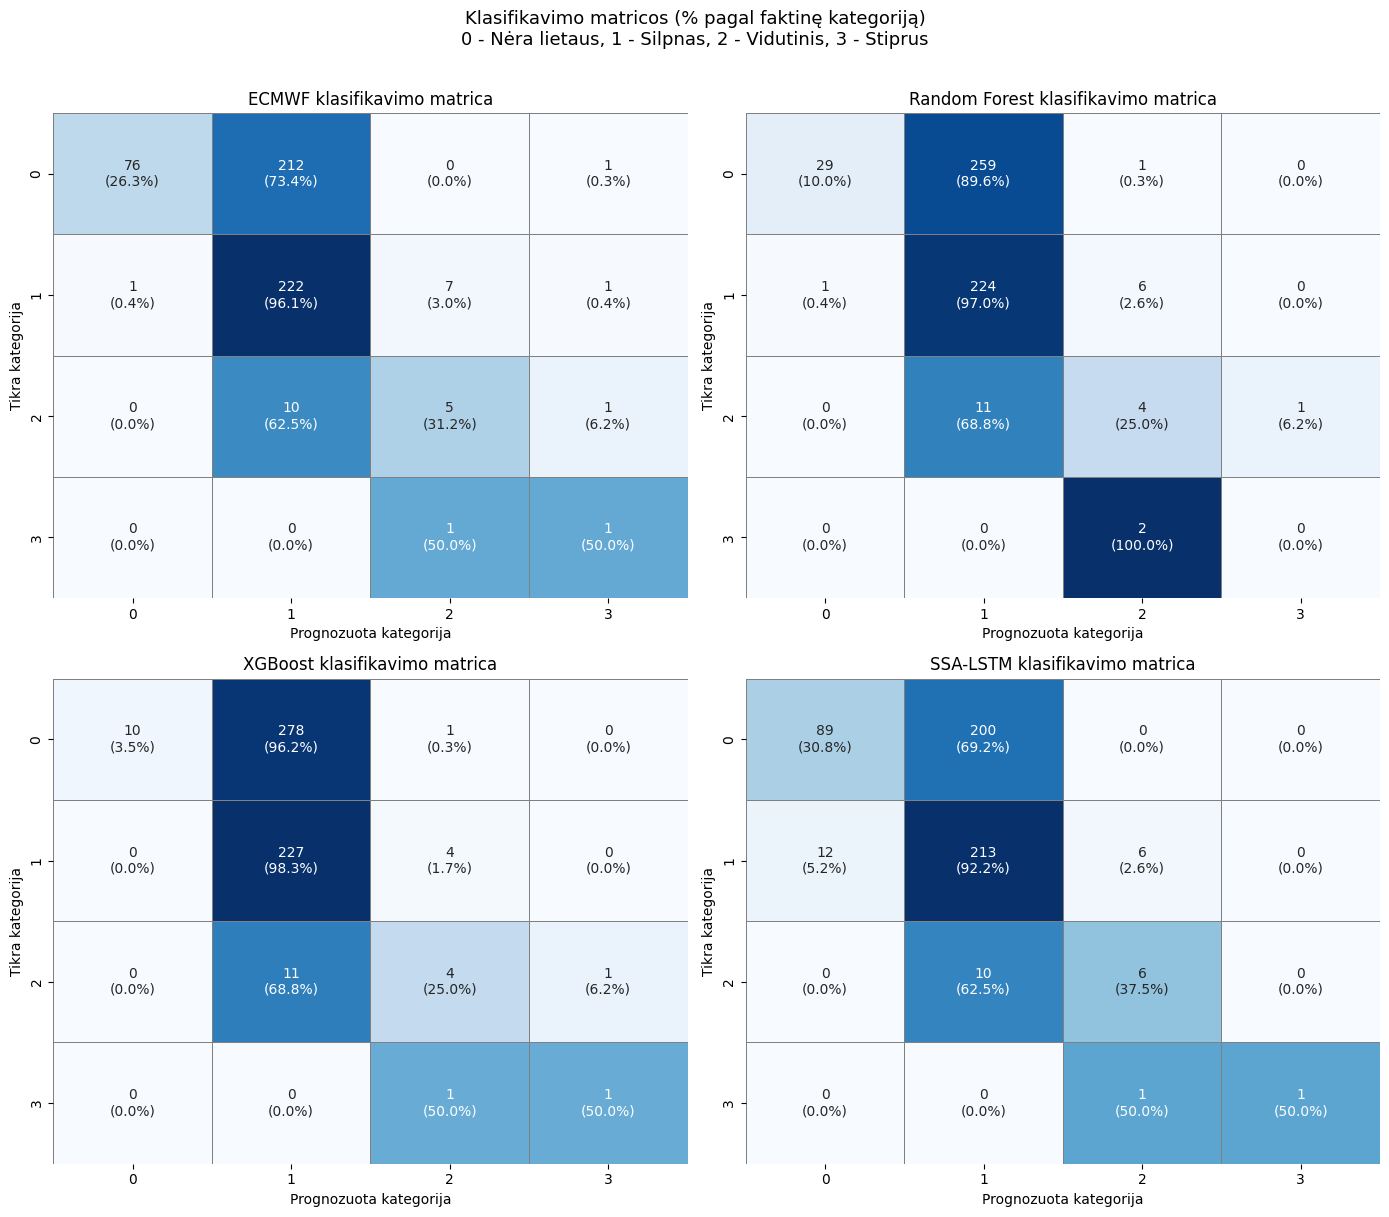

In [186]:
plot_confusion_matrices_kategorijos(df, MODEL_COLS)

### Tik test aibė (paskutiniai metai)

In [187]:
paskutine_data = df['observationTime'].max()
pries_metus = paskutine_data - pd.Timedelta(days=365)
df_365 = df[(df['observationTime'] > pries_metus) & (df['observationTime'] <= paskutine_data)]
print(f"Paskutinių 12 mėn. duomenų taškai: {len(df_365)}")

Paskutinių 12 mėn. duomenų taškai: 365


In [188]:
metrikos_365 = metrikos_lentele(df_365, MODEL_COLS, TARGET_COL)
print(metrikos_365.to_string(index=False))

      Modelis    R^2    MAE   RMSE    r_s
        ECMWF 0.4846 1.4452 3.1535 0.7647
Random Forest 0.5683 1.4049 2.8861 0.7246
      XGBoost 0.5523 1.3588 2.9392 0.7228
     SSA-LSTM 0.4019 1.5909 3.3970 0.6298


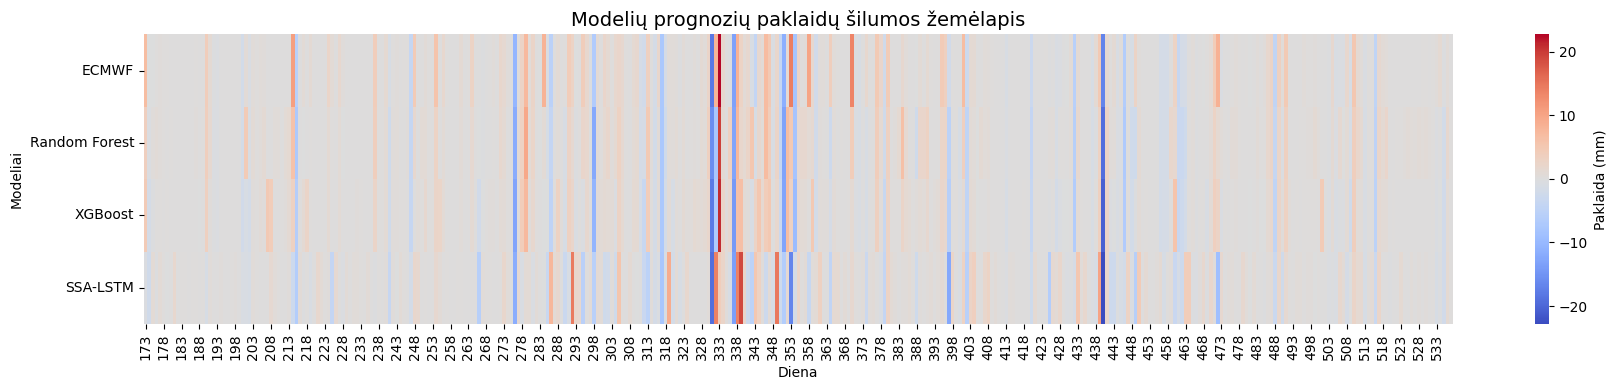

In [189]:
plot_error_heatmap(df_365, MODEL_COLS)

### Itrauktas ansamblis

In [190]:
df_ensemble = pd.read_csv("All_with_ensemble_rf.csv")
df_ensemble['observationTime'] = pd.to_datetime(df_ensemble['observationTime'])
df_ensemble.columns.to_list()
pradzia = df_ensemble['observationTime'].min()
pabaiga = df_ensemble['observationTime'].max()
print(pradzia, pabaiga)

2024-02-02 00:00:00 2026-01-31 00:00:00


In [191]:
df_combined = pd.merge(df_ensemble, df[["observationTime", "SSA-LSTM"]],
                       on="observationTime", how="left")

first_valid = df_combined["ensemble_rf_pred"].first_valid_index()
df_final = df_combined.loc[first_valid:].dropna().copy()

print(f"Pradžios data po nukirpimo: {df_final['observationTime'].min()}")
print(f"Eilučių: {len(df_final)}")


Pradžios data po nukirpimo: 2025-09-08 00:00:00
Eilučių: 145


In [192]:
MODEL_COLS_ENS = ["ECMWF", "rf_prediction", "xgb_predicted", "SSA-LSTM", "ensemble_rf_pred"]

metrikos_ens = metrikos_lentele(df_final, MODEL_COLS_ENS, TARGET_COL)
print(metrikos_ens.to_string(index=False))

       Modelis    R^2    MAE   RMSE    r_s
         ECMWF 0.6461 1.0555 2.2799 0.7706
 Random Forest 0.6389 1.0865 2.3029 0.7264
       XGBoost 0.6084 1.0439 2.3981 0.7498
      SSA-LSTM 0.4094 1.4098 2.9452 0.6157
Ansamblis (RF) 0.6658 0.9783 2.2155 0.7615


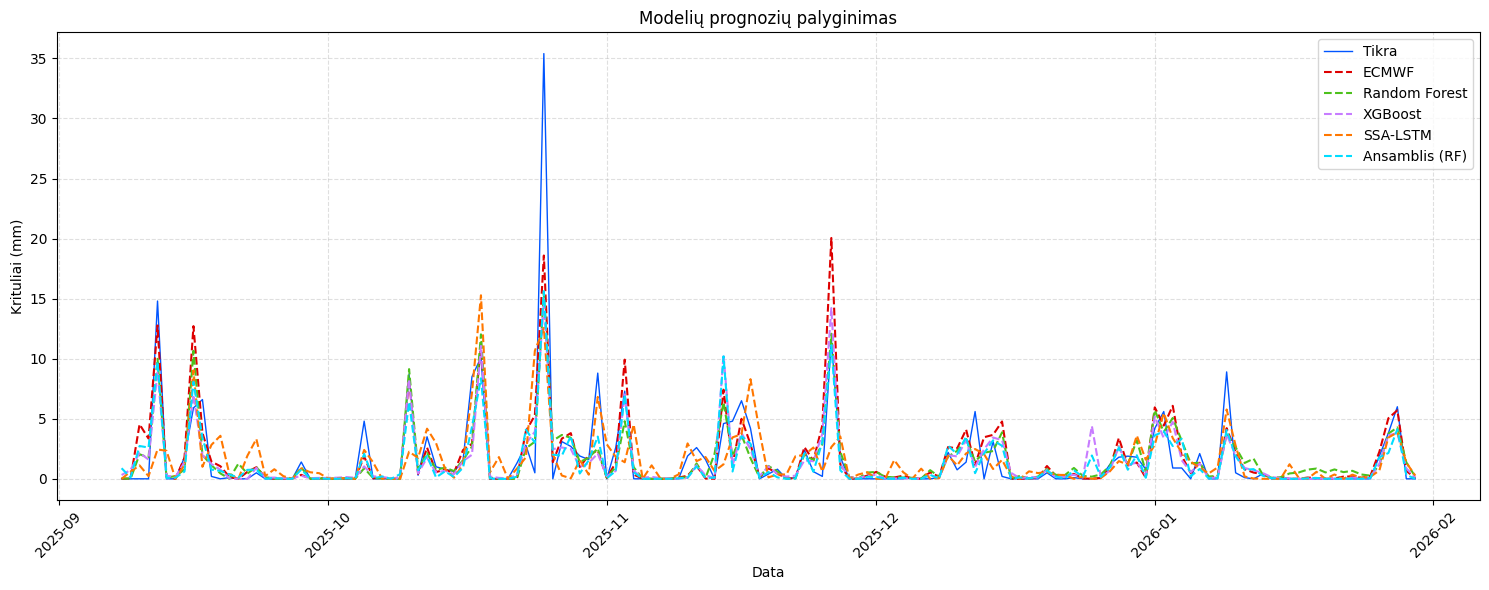

In [193]:
plot_prognozes_matplotlib(df_final, MODEL_COLS_ENS)

In [194]:
plot_prognozes_plotly(df_final, MODEL_COLS_ENS)